In [59]:
import sys
import os
import csv
import pandas as pd
import snowflake.connector
from sklearn.model_selection import train_test_split
import itertools
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb

In [ ]:
def add_query_id(blind_pass_df):
    #this function will take a dataframe and assemble query sets that represent every availble accuracy
    #each query set will contain all possible accuracies
    #the goal being that we can train a lambda mart model to rank these sets and work generally to identify accuracy
    all_possible_accuraracies = np.unique(np.round(blind_pass_df['accuracy'].unique(),2)).tolist()
    #establish an array to see if the current cluster has already been added to a query set
    cluster_already_used = np.zeros(len(blind_pass_df), dtype=bool)
    query_id = np.full(len(blind_pass_df), np.nan)
    current_query_id = 0
    tracker_counter = 0;
    for cluster_idx in range(len(blind_pass_df)):
        if cluster_already_used[cluster_idx]:
            print("Finished "+str(cluster_idx)+"/"+str(len(blind_pass_df)))
            tracker_counter += 1
            continue

        available_accuracies = (
        np.round(blind_pass_df.loc[~cluster_already_used, "accuracy"], 2)
        .unique()
        .tolist()
    )
        for accuracy in available_accuracies:
            #print(accuracy)
            mask = (np.round(blind_pass_df["accuracy"])== np.round(accuracy)) & (~cluster_already_used)
            if not mask.any():
                continue
            #print(mask)
            idx = blind_pass_df.loc[mask].index[0]
            query_id[idx] = current_query_id
            cluster_already_used[idx] = True
            print("Finished "+str(tracker_counter)+"/"+str(len(blind_pass_df)))
            tracker_counter += 1
        current_query_id += 1
    
    #now add the query id to the dataframe
    blind_pass_df['query_id'] = query_id
    return blind_pass_df


In [123]:
#make all scripts available to this notebook
nested_dir_path = os.path.join(os.getcwd(), '..', '..',"Clustering_neuron_spikes_with_deep_learning")
sys.path.append(nested_dir_path)
print(nested_dir_path)

c:\Users\ldd77\clustering_neuron_spikes_with_deep_learning\Neural_Networks\NN_training_scripts\..\..\Clustering_neuron_spikes_with_deep_learning


In [12]:
#import data that will be used for training
data = pd.read_csv(r"C:\Users\ldd77\clustering_neuron_spikes_with_deep_learning\Default_Results_Dir\lambda_mart_features.csv")
data.head()

,cv,Mean SNR,Elipse Temp Match,Circle Temp Match,SNR based on 2 Compare Wires,cluster mpc,cv with 0.5,Compare Wire tightness of waveform based on euc dist,snr 0.24 compare wire,cv with 0.33,...,1st_valley_4,2nd_valley_1,2nd_valley_2,2nd_valley_3,2nd_valley_4,z_score,tetrode,cluster,accuracy,recording
0,0.089935,0.194494,0.382722,0.619548,-0.187185,0.159451,0.189642,0.093487,0.010555,0.309045,...,0.448175,0.879286,0.427092,0.754253,0.367895,3,t1,1,30.513011,6_600Neuron300SecondRecordingWithLevel6Noise
1,0.094178,0.045736,0.497368,0.431864,-0.302430,0.225870,0.201465,0.191830,0.018563,0.389723,...,0.263975,0.292899,0.350679,0.364785,0.605589,3,t1,2,21.174632,6_600Neuron300SecondRecordingWithLevel6Noise
2,0.075771,-0.233839,0.197329,0.423585,-0.254581,0.192440,0.242395,0.168766,0.026667,0.408240,...,0.359082,0.626332,0.644680,0.468385,1.445857,3,t1,3,27.021597,6_600Neuron300SecondRecordingWithLevel6Noise
3,0.083022,-0.221348,0.393429,0.640025,-0.441508,0.202794,0.186874,0.168154,0.002262,0.293087,...,0.569562,0.746483,0.290253,0.307989,0.402400,3,t1,4,48.837950,6_600Neuron300SecondRecordingWithLevel6Noise
4,0.091072,-0.783914,0.083458,0.659825,-0.883581,0.182744,0.400817,0.275644,0.280488,0.982233,...,0.477496,0.859930,0.698858,0.685132,0.668757,3,t1,5,46.461758,6_600Neuron300SecondRecordingWithLevel6Noise


In [124]:
#filter the training data down to only recordings 6,7,8
training_data = data[(data["recording"] == "6_600Neuron300SecondRecordingWithLevel6Noise") | (data["recording"] == "7_600Neuron300SecondRecordingWithLevel7Noise")  | (data["recording"] == "8_600Neuron300SecondRecordingWithLevel8Noise")] 
#reset the index of the training data
training_data = training_data.reset_index(drop=True)
#get the validation data to recording 9
validation_data = data[data["recording"] == "9_600Neuron300SecondRecordingWithLevel9Noise"]
#reset the index of the validation data
validation_data = validation_data.reset_index(drop=True)
#get the test data to recording 10
test_data = data[data["recording"] == "10_600Neuron300SecondRecordingWithLevel10Noise"]
#reset the index of the test data
test_data = test_data.reset_index(drop=True)
#print heads and size of each dataset
print("Training Data:")
print(training_data.head())
print("Size of Training Data:", len(training_data))
print("Validation Data:")
print(validation_data.head())
print("size of Validation Data:", len(validation_data))
print("Test Data:")
print(test_data.head())
print("size of Test Data:", len(test_data))

Training Data:
         cv  Mean SNR  Elipse Temp Match  Circle Temp Match  \
0  0.089935  0.194494           0.382722           0.619548   
1  0.094178  0.045736           0.497368           0.431864   
2  0.075771 -0.233839           0.197329           0.423585   
3  0.083022 -0.221348           0.393429           0.640025   
4  0.091072 -0.783914           0.083458           0.659825   

   SNR based on 2 Compare Wires  cluster mpc  cv with 0.5  \
0                     -0.187185     0.159451     0.189642   
1                     -0.302430     0.225870     0.201465   
2                     -0.254581     0.192440     0.242395   
3                     -0.441508     0.202794     0.186874   
4                     -0.883581     0.182744     0.400817   

   Compare Wire tightness of waveform based on euc dist  \
0                                           0.093487      
1                                           0.191830      
2                                           0.168766      
3  

In [125]:
# add query ids to each dataset
training_data = add_query_id(training_data)
validation_data = add_query_id(validation_data)
test_data = add_query_id(test_data)

Finished 0/44303
Finished 1/44303
Finished 2/44303
Finished 3/44303
Finished 4/44303
Finished 5/44303
Finished 6/44303
Finished 7/44303
Finished 8/44303
Finished 9/44303
Finished 10/44303
Finished 11/44303
Finished 12/44303
Finished 13/44303
Finished 14/44303
Finished 15/44303
Finished 16/44303
Finished 17/44303
Finished 18/44303
Finished 19/44303
Finished 20/44303
Finished 21/44303
Finished 22/44303
Finished 23/44303
Finished 24/44303
Finished 25/44303
Finished 26/44303
Finished 27/44303
Finished 28/44303
Finished 29/44303
Finished 30/44303
Finished 31/44303
Finished 32/44303
Finished 33/44303
Finished 34/44303
Finished 35/44303
Finished 36/44303
Finished 37/44303
Finished 38/44303
Finished 39/44303
Finished 40/44303
Finished 41/44303
Finished 42/44303
Finished 43/44303
Finished 44/44303
Finished 45/44303
Finished 46/44303
Finished 47/44303
Finished 48/44303
Finished 49/44303
Finished 50/44303
Finished 51/44303
Finished 52/44303
Finished 53/44303
Finished 54/44303
Finished 55/44303
Fi

In [159]:
#get the true relevance classes for training, validation, and test data
Y_train = np.round(training_data['accuracy'].to_numpy())
Y_val = np.round(validation_data['accuracy'].to_numpy())
Y_test = np.round(test_data['accuracy'].to_numpy())

In [ ]:
# rows + group lengths
train_sorted = training_data.sort_values("query_id").reset_index(drop=True)
val_sorted = validation_data.sort_values("query_id").reset_index(drop=True)
test_sorted = test_data.sort_values("query_id").reset_index(drop=True)

# drop rows that never got assigned a query_id
train_sorted = train_sorted.dropna(subset=["query_id"])
val_sorted = val_sorted.dropna(subset=["query_id"])
test_sorted = test_sorted.dropna(subset=["query_id"])

train_group = train_sorted.groupby("query_id").size().to_numpy()
val_group = val_sorted.groupby("query_id").size().to_numpy()
test_group = test_sorted.groupby("query_id").size().to_numpy()

assert train_group.sum() == len(train_sorted)
assert val_group.sum() == len(val_sorted)
assert test_group.sum() == len(test_sorted)

features_to_drop = ["recording", "accuracy", "z_score", "tetrode", "cluster", "query_id"]

X_train = train_sorted.drop(columns=features_to_drop).to_numpy()
Y_train = np.round(train_sorted["accuracy"]).astype(int) - 1
X_val = val_sorted.drop(columns=features_to_drop).to_numpy()
Y_val = np.round(val_sorted["accuracy"]).astype(int) - 1
X_test = test_sorted.drop(columns=features_to_drop).to_numpy()
Y_test = np.round(test_sorted["accuracy"]).astype(int) - 1

model = lgb.LGBMRanker(objective="lambdarank", metric="ndcg", label_gain=list(range(100)),verbose=1, n_estimators=1000)
model.fit(
    X=X_train,
    y=Y_train,
    group=train_group,
    eval_set=[(X_val, Y_val)],
    eval_group=[val_group],
    eval_at=100,
)
results = model.evals_result_


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5872
[LightGBM] [Info] Number of data points in the train set: 44303, number of used features: 26


KeyError: 'ndcg@10'

dict_keys(['valid_0'])
odict_keys(['ndcg@100'])


Text(0, 0.5, 'NDCG@100')

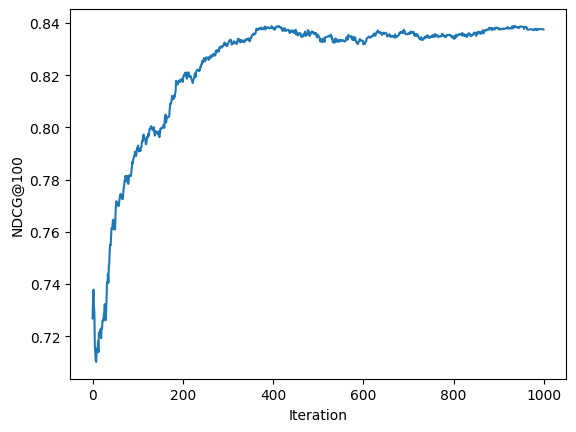

In [181]:
results = model.evals_result_
print(results.keys())            # usually ['training', 'valid_0']
print(results['valid_0'].keys()) # see exact metric names, e.g. dict_keys(['ndcg@100'])
plt.plot(results["valid_0"]["ndcg@100"])
plt.xlabel("Iteration")
plt.ylabel("NDCG@100")
